Question 1:
Build a Bagging Classifier using Decision Trees to predict whether a customer will buy a product based on their age, income, and spending score.

Evaluate accuracy.

Compare with a single Decision Tree model.

Visualize the comparison.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("C:/Users/anura/Downloads/customer_purchase_data.csv")

# Features and target
X = df[['Age', 'Income', 'SpendingScore']]
y = df['Purchase']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [2]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)


Decision Tree Accuracy: 0.5166666666666667


In [3]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(estimator=DecisionTreeClassifier(),
                        n_estimators=50, random_state=42)

bag.fit(X_train, y_train)

# Predict
y_pred_bag = bag.predict(X_test)

# Accuracy
acc_bag = accuracy_score(y_test, y_pred_bag)
print("Bagging Classifier Accuracy:", acc_bag)


Bagging Classifier Accuracy: 0.6


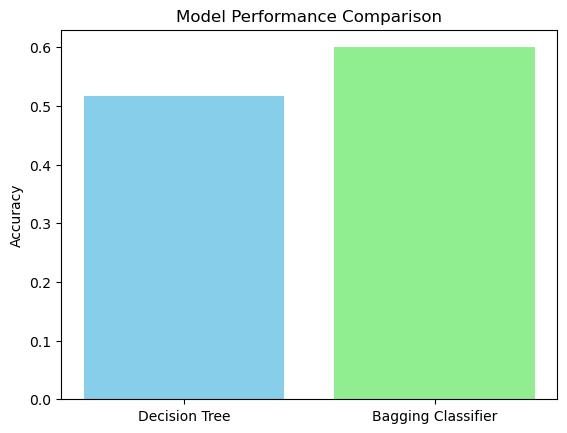

In [4]:
plt.bar(['Decision Tree', 'Bagging Classifier'], [acc_dt, acc_bag], color=['skyblue', 'lightgreen'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.show()


Practice Question 2:
Q:
Build a Boosting Regressor (use AdaBoost or GradientBoosting) to predict house prices based on features like number of rooms, size (in sq ft), distance from city center, and age of the house.

Compare performance with a simple Linear Regression.

Visualize actual vs predicted values for both models.

In [13]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df2 = pd.read_csv("C:/Users/anura/Downloads/better_house_price_data.csv")

# Features and target
X2 = df2[['Rooms', 'Size_sqft', 'Distance_CityCenter', 'Age_House']]
y2 = df2['Price']

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=42)


In [14]:
lr = LinearRegression()
lr.fit(X2_train, y2_train)

# Predict
y2_pred_lr = lr.predict(X2_test)

# Evaluate
mse_lr = mean_squared_error(y2_test, y2_pred_lr)
r2_lr = r2_score(y2_test, y2_pred_lr)
print("Linear Regression R²:", r2_lr)


Linear Regression R²: 0.9690857347545603


In [15]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X2_train, y2_train)

# Predict
y2_pred_gbr = gbr.predict(X2_test)

# Evaluate
mse_gbr = mean_squared_error(y2_test, y2_pred_gbr)
r2_gbr = r2_score(y2_test, y2_pred_gbr)
print("Gradient Boosting R²:", r2_gbr)


Gradient Boosting R²: 0.9212452455123454


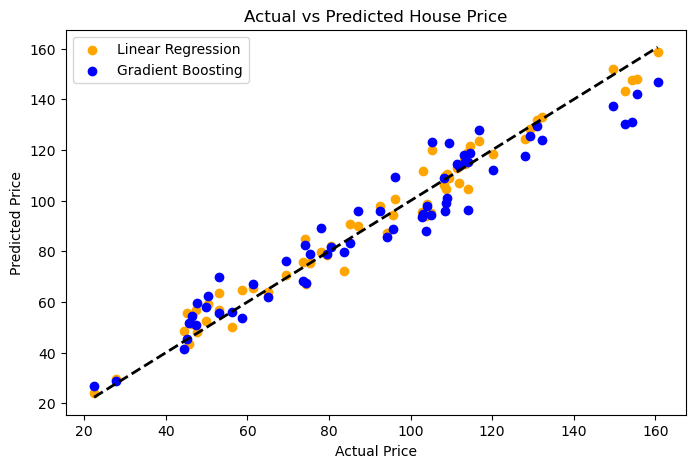

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y2_test, y2_pred_lr, color='orange', label='Linear Regression')
plt.scatter(y2_test, y2_pred_gbr, color='blue', label='Gradient Boosting')
plt.plot([y2_test.min(), y2_test.max()], [y2_test.min(), y2_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.title('Actual vs Predicted House Price')
plt.show()
